# **Task 3: Customer Churn Prediction (Bank Customers)**

**Objective**:

Predicted which customers are likely to exit the bank.

**Load Dataset & Libraries**

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#  Load Dataset
df = pd.read_csv('Churn_Modelling.csv')
print("Dataset Loaded!")
df.head()

Dataset Loaded!


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Data Cleaning & Feature Selection**

Cleaned the dataset by removing unique identifiers

In [20]:
# Drop unnecessary columns
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(" Dataset Cleaned")


 Dataset Cleaned


**Encoding Categorical Features**

applied One-Hot Encoding to categorical variables like 'Gender' and 'Geography'

In [21]:
# Encoding Gender (Label Encoding)
# Encode Geography and Gender
df_encoded = pd.get_dummies(df_clean, columns=['Geography', 'Gender'], drop_first=True)
print("Categorical features encoded")

Categorical features encoded


**Train a Classification Model**

Used Random Forest Classifier to handle non-linear relationships

In [22]:
# Define Features (X) and Target (y)
X = df_encoded.drop('Exited', axis=1) # 'Exited' is the churn column
y = df_encoded['Exited']

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Random Forest Model trained")

Random Forest Model trained


**Analyze Results & Feature Importance**

In [23]:
# Understand what influences churn
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"\n MODEL ACCURACY: {accuracy*100:.2f}%")

# Calculate Feature Importance
importance = pd.DataFrame({
    'Factor': X.columns,
    'Importance (%)': model.feature_importances_ * 100
}).sort_values(by='Importance (%)', ascending=False)

print("\nTOP FACTORS INFLUENCING CHURN:")
print(importance.head(5).to_string(index=False))


 MODEL ACCURACY: 86.65%

TOP FACTORS INFLUENCING CHURN:
         Factor  Importance (%)
            Age       23.692176
EstimatedSalary       14.755811
    CreditScore       14.333835
        Balance       14.161247
  NumOfProducts       13.148586


**Visualizing the Insights**

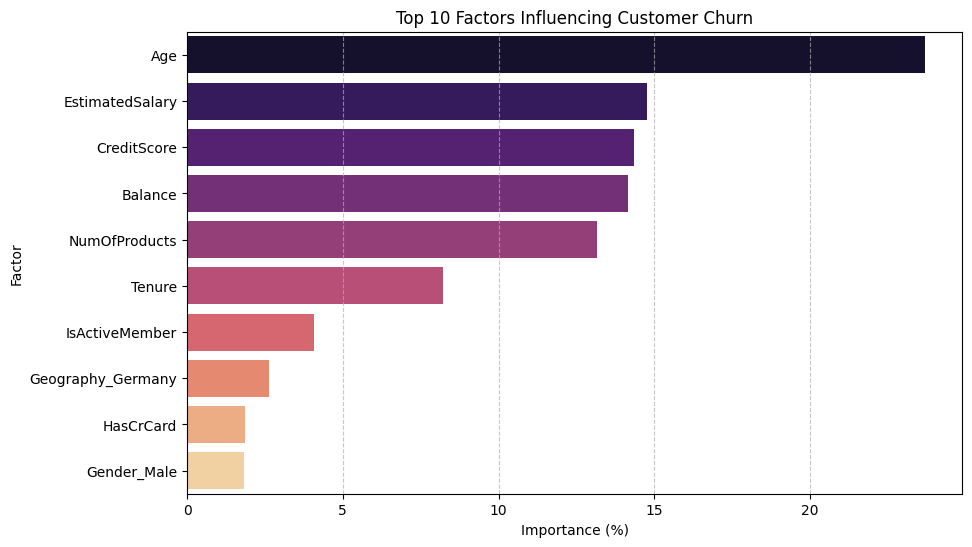

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance (%)', y='Factor', data=importance.head(10), hue='Factor', palette='magma', legend=False)
plt.title("Top 10 Factors Influencing Customer Churn")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Key Takeaways**

In Churn Prediction, "Age" was identified as the primary drivers, allowing banks to create targeted retention strategies for high-risk groups.